In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_excel("heart_disease.xlsx" ,sheet_name="Heart_disease")

print(df.head())
print(df.info())
print(df.isnull().sum())

   age   sex               cp  trestbps  chol    fbs         restecg  thalch  \
0   63  Male   typical angina       145   233   True  lv hypertrophy     150   
1   41  Male  atypical angina       135   203  False          normal     132   
2   57  Male     asymptomatic       140   192  False          normal     148   
3   52  Male   typical angina       118   186  False  lv hypertrophy     190   
4   57  Male     asymptomatic       110   201  False          normal     126   

   exang  oldpeak        slope          thal  num  
0  False      2.3  downsloping  fixed defect    0  
1  False      0.0         flat  fixed defect    0  
2  False      0.4         flat  fixed defect    0  
3  False      0.0         flat  fixed defect    0  
4   True      1.5         flat  fixed defect    0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-n

In [2]:
df = df.apply(pd.to_numeric, errors='coerce')
df = df.dropna(axis=1, how='all')

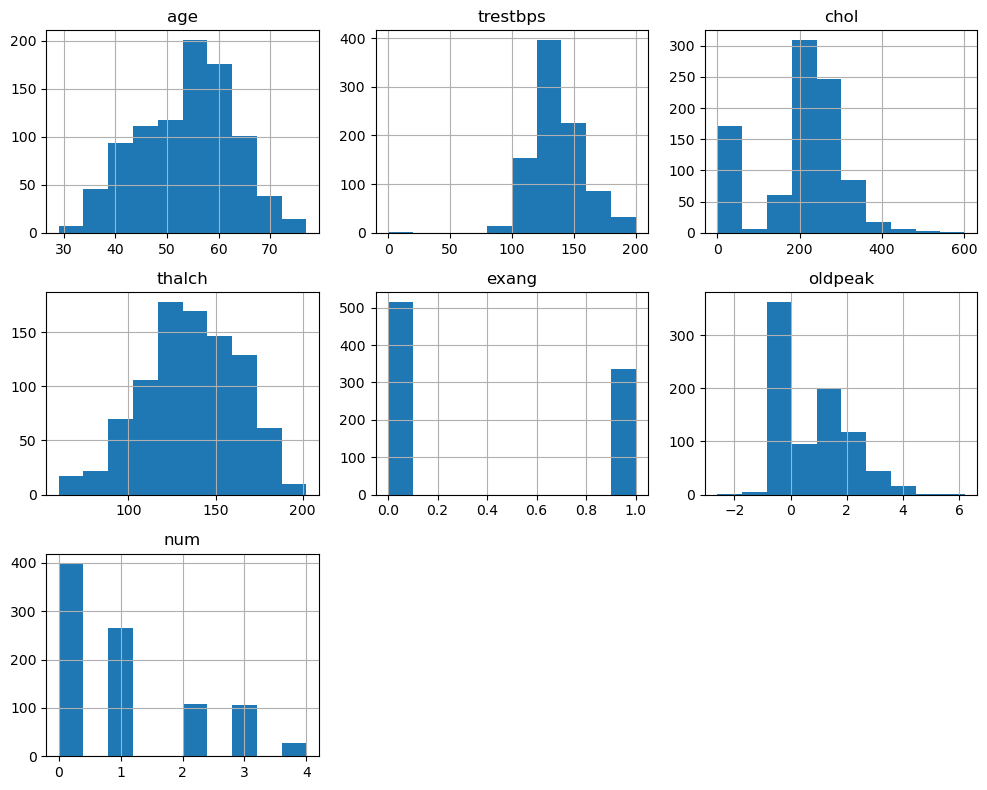

In [3]:
#Histogram
df.hist(figsize=(10,8))
plt.tight_layout()
plt.show()

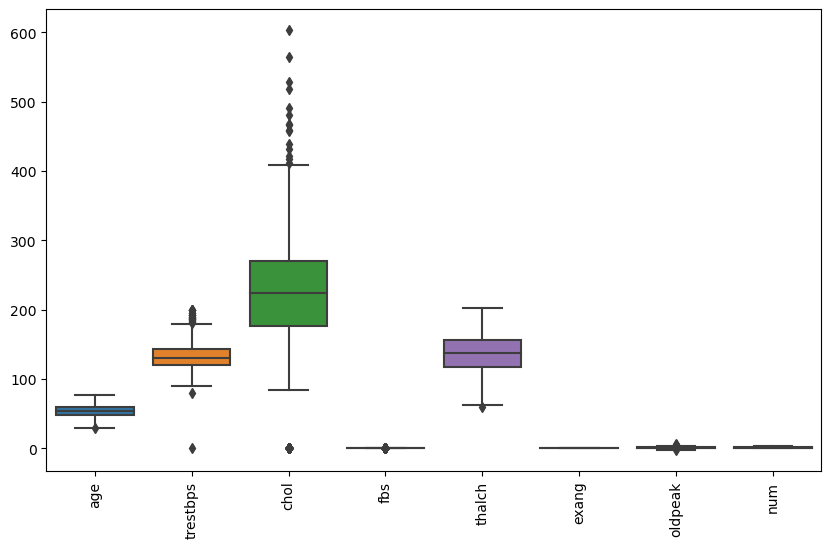

In [4]:
# Boxplot (outliers)
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

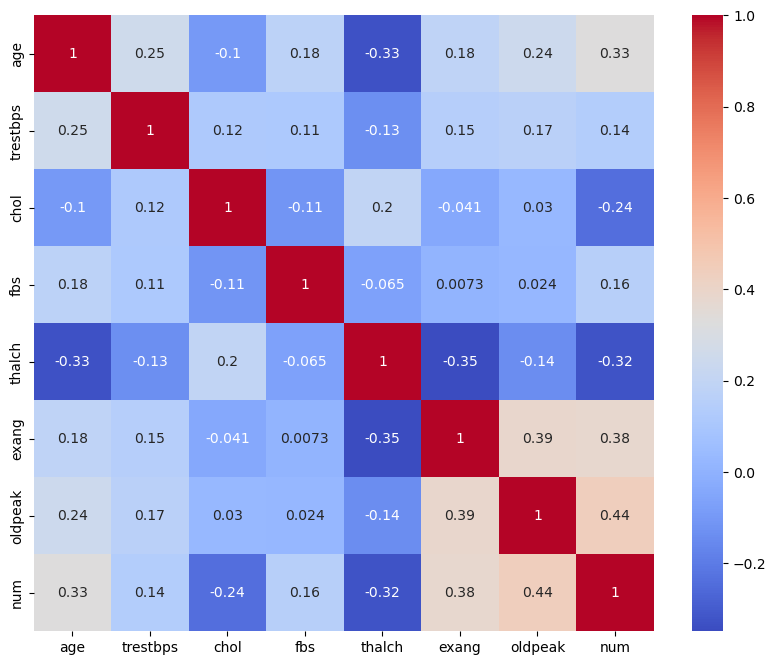

In [12]:
# Correlation Matrix
df.columns = df.columns.str.strip()  # remove spaces

if 'sex' in df.columns:
    df['sex'] = df['sex'].map({'Male': 1, 'Female': 0})

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [13]:
X = df.drop("num", axis=1)
y = df["num"]

In [14]:
y = y.apply(lambda x: 1 if x > 0 else 0)

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [17]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7087912087912088

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.64      0.68        89
           1       0.69      0.77      0.73        93

    accuracy                           0.71       182
   macro avg       0.71      0.71      0.71       182
weighted avg       0.71      0.71      0.71       182


Confusion Matrix:
 [[57 32]
 [21 72]]


In [18]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}


In [19]:
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

print("Tuned Accuracy:", accuracy_score(y_test, y_pred_best))

Tuned Accuracy: 0.7912087912087912


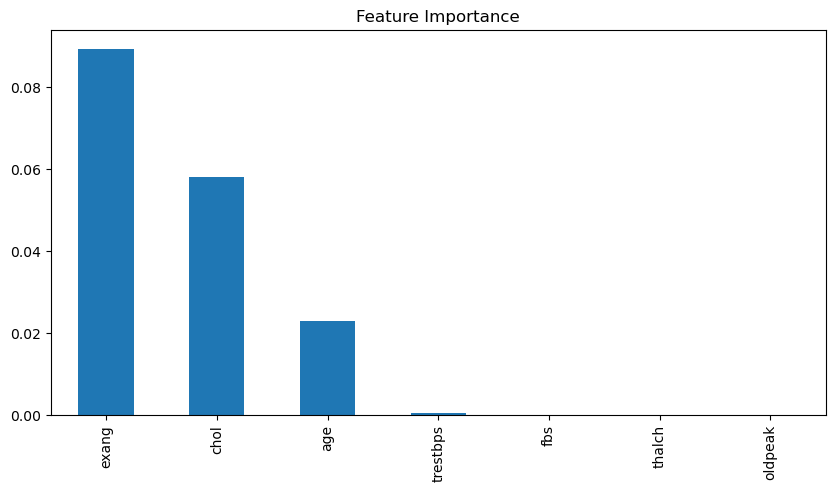

In [20]:
importance = pd.Series(best_model.feature_importances_, index=X.columns)

importance.sort_values(ascending=False).plot(kind='bar', figsize=(10,5))
plt.title("Feature Importance")
plt.show()

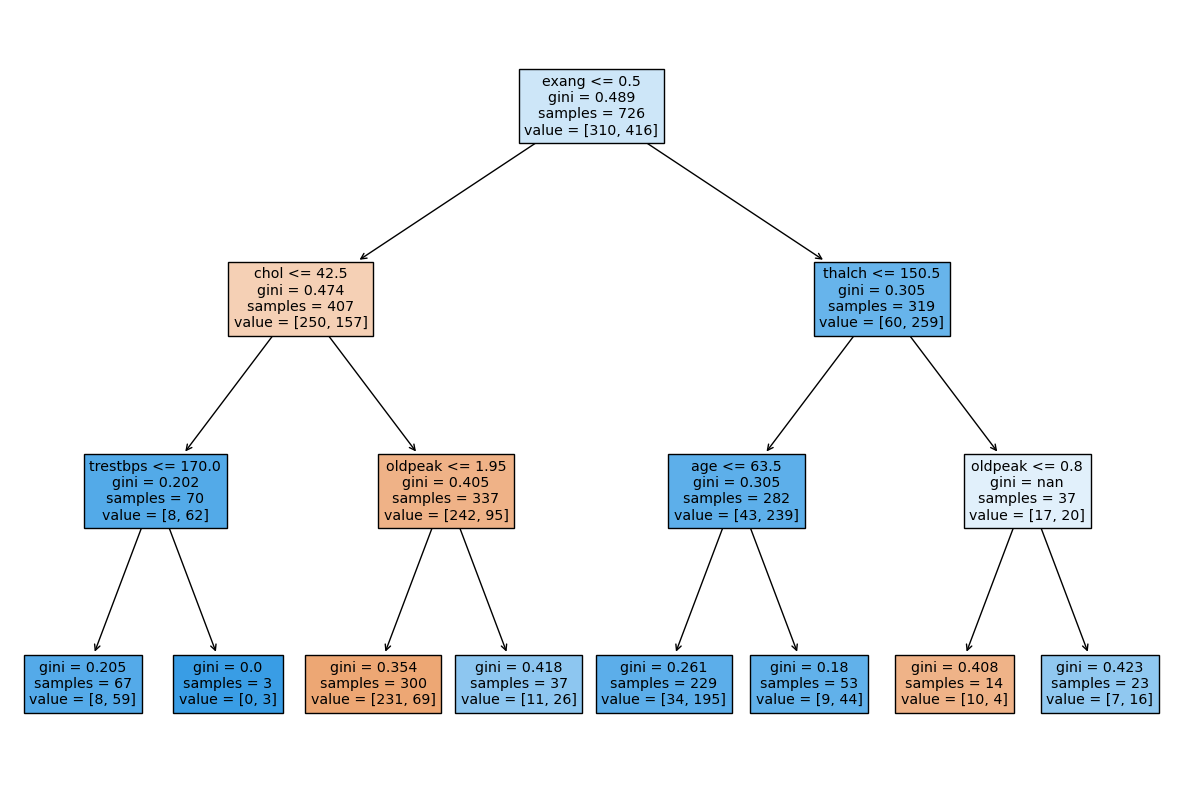

In [22]:
from sklearn.tree import plot_tree
plt.figure(figsize=(15,10))

plot_tree(
    best_model,
    filled=True,
    feature_names=list(X.columns)
)

plt.show()